In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az

from cmdstanpy import CmdStanModel

In [10]:
data = pd.read_csv("data/generated_data.csv", delimiter=",", header=0)

data_dict = {
    "N": len(data),
    "x": data.X.values,
    "y": data.Y.values,
}

In [3]:
model = CmdStanModel(
    stan_file="models/regression_model.stan"
)

11:31:19 - cmdstanpy - INFO - compiling stan file C:\Users\benwertz\Documents\GitHub\CognitiveModeling_TestRepo\hw3\problem6\models\regression_model.stan to exe file C:\Users\benwertz\Documents\GitHub\CognitiveModeling_TestRepo\hw3\problem6\models\regression_model.exe
11:33:11 - cmdstanpy - INFO - compiled model executable: C:\Users\benwertz\Documents\GitHub\CognitiveModeling_TestRepo\hw3\problem6\models\regression_model.exe


In [11]:
# just using the same parameters we used in class for now
# because they worked and I'm scared of changing them
fit = model.sample(
    data=data_dict, 
    chains=4, 
    iter_warmup=500, 
    iter_sampling=5000,
)

11:40:09 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/5500 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/5500 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/5500 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/5500 [00:00<?, ?it/s, (Warmup)]

11:40:09 - cmdstanpy - INFO - CmdStan done processing.


In [28]:
fit.summary()

,Mean,MCSE,StdDev,5%,50%,95%,N_Eff,N_Eff/s,R_hat
lp__,-126.68700,0.013922,1.270060,-129.17000,-126.35100,-125.33700,8322.45,4849.92,1.00023
alpha,-11.43250,0.009967,1.137010,-13.26940,-11.44790,-9.53991,13012.80,7583.22,1.00018
beta,9.84681,0.010324,1.185640,7.90508,9.85245,11.81870,13188.20,7685.43,1.00005
sigma2,46.99760,0.087011,9.772030,33.51200,45.68740,64.49040,12613.20,7350.35,1.00021
sigma,6.82021,0.006083,0.694506,5.78896,6.75924,8.03059,13034.70,7595.96,1.00021


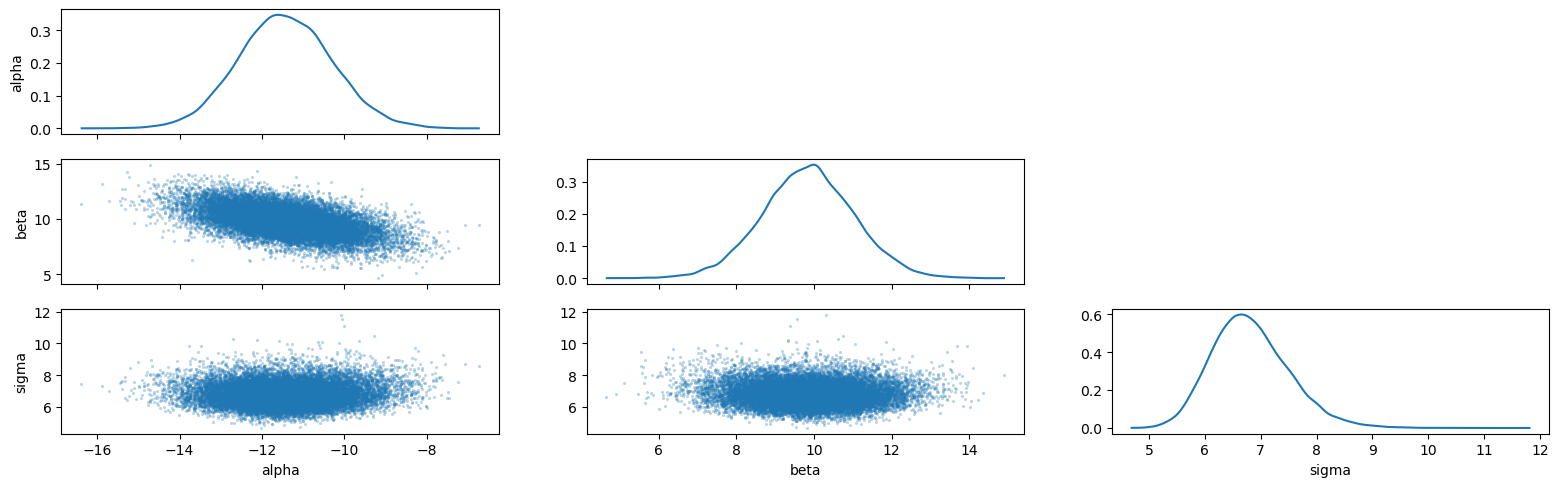

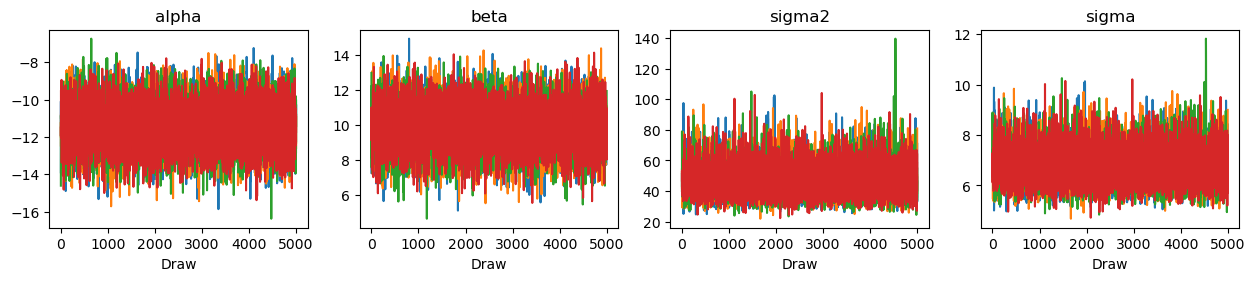

In [ ]:
idata = az.from_cmdstanpy(
    posterior=fit,
    observed_data={"y": data_dict["y"]}
)
idata
az.plot_pair(
    idata,var_names=["alpha","beta","sigma"],
    visuals={"scatter":{"alpha":0.3,"size":5}}
)
az.plot_trace(idata)

In [15]:
idata.posterior["alpha"].data.size

20000

Median:
	alpha = -11.4480
	beta  =  9.8524
	sigma =  6.7592


Text(0, 0.5, 'Y')

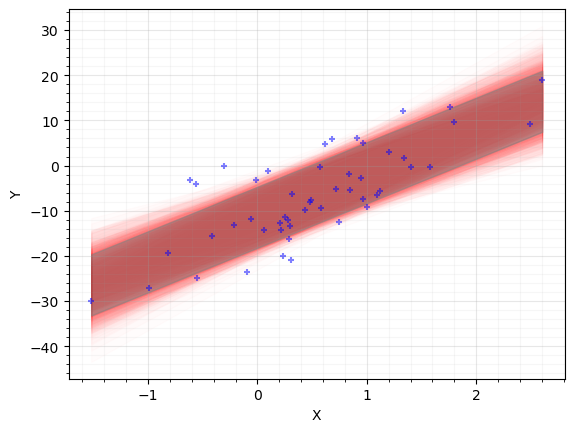

In [26]:
# N_posterior=len(idata.posterior["alpha"].flatten())
pl_X=np.linspace(data_dict["x"].min(),data_dict["x"].max(),2)

N_plot=100
for i in np.random.randint(0,idata.posterior["alpha"].size,N_plot):
    _pl_Y=idata.posterior["alpha"].data.flatten()[i]+idata.posterior["beta"].data.flatten()[i]*pl_X
    _pl_Y_low=_pl_Y-idata.posterior["sigma"].data.flatten()[i]
    _pl_Y_high=_pl_Y+idata.posterior["sigma"].data.flatten()[i]
    plt.fill_between(
        pl_X,
        _pl_Y_low,
        _pl_Y_high,
        color="r",
        alpha=0.01,
    )

alpha_med=np.median(idata.posterior["alpha"].data.flatten())
beta_med=np.median(idata.posterior["beta"].data.flatten())
sigma_med=np.median(idata.posterior["sigma"].data.flatten())
print(f"Median:\n\talpha = {alpha_med: .4f}\n\tbeta  = {beta_med: .4f}\n\tsigma =  {sigma_med:.4f}")

pl_Y_low=alpha_med+pl_X*beta_med-sigma_med
pl_Y_high=alpha_med+pl_X*beta_med+sigma_med


plt.fill_between(
    pl_X,
    pl_Y_low,
    pl_Y_high,
    color="gray",
    alpha=0.5,
    zorder=1000
)
plt.scatter(data_dict["x"],data_dict["y"],marker="+",s=20,c="b",alpha=0.5,zorder=1001)

plt.minorticks_on()
plt.grid(which="major",alpha=0.3)
plt.grid(which="minor",alpha=0.1)
plt.xlabel("X")
plt.ylabel("Y")
